In [ ]:
!pip install gradio -q

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from scipy.spatial.distance import directed_hausdorff
import gradio as gr
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
from tqdm import tqdm
import zipfile

# Upload your zip file
uploaded = files.upload()

zip_path = list(uploaded.keys())[0]
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()
    for file in tqdm(file_list, desc="Extracting"):
        zip_ref.extract(file, extract_path)

print("Extraction complete!")

# Check folder structure
for root, dirs, files_list in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    if level < 3:
        print(" " * 2 * level + os.path.basename(root) + "/")

Saving archive (11).zip to archive (11).zip


Extracting: 100%|██████████| 77740/77740 [00:11<00:00, 7063.15it/s]


Extraction complete!
dataset/
  LIDC-IDRI-slices/
    LIDC-IDRI-0794/
    LIDC-IDRI-0172/
    LIDC-IDRI-0565/
    LIDC-IDRI-0591/
    LIDC-IDRI-0387/
    LIDC-IDRI-0129/
    LIDC-IDRI-0827/
    LIDC-IDRI-0631/
    LIDC-IDRI-0919/
    LIDC-IDRI-0274/
    LIDC-IDRI-0305/
    LIDC-IDRI-0801/
    LIDC-IDRI-0163/
    LIDC-IDRI-0118/
    LIDC-IDRI-0343/
    LIDC-IDRI-0159/
    LIDC-IDRI-0597/
    LIDC-IDRI-0311/
    LIDC-IDRI-0286/
    LIDC-IDRI-0866/
    LIDC-IDRI-0478/
    LIDC-IDRI-0580/
    LIDC-IDRI-1010/
    LIDC-IDRI-0101/
    LIDC-IDRI-0374/
    LIDC-IDRI-0448/
    LIDC-IDRI-0496/
    LIDC-IDRI-0292/
    LIDC-IDRI-0115/
    LIDC-IDRI-0904/
    LIDC-IDRI-0125/
    LIDC-IDRI-0431/
    LIDC-IDRI-0871/
    LIDC-IDRI-0058/
    LIDC-IDRI-0433/
    LIDC-IDRI-0696/
    LIDC-IDRI-0726/
    LIDC-IDRI-0491/
    LIDC-IDRI-0844/
    LIDC-IDRI-0590/
    LIDC-IDRI-0182/
    LIDC-IDRI-0246/
    LIDC-IDRI-0386/
    LIDC-IDRI-0398/
    LIDC-IDRI-1006/
    LIDC-IDRI-0562/
    LIDC-IDRI-0838/
    LIDC-I

In [ ]:
# After extraction, check what your actual path is
# and set it correctly here

dataset_path = "/content/dataset/LIDC-IDRI-slices"  # change if needed

# Verify it exists
if os.path.exists(dataset_path):
    patients = os.listdir(dataset_path)
    print(f"Found {len(patients)} patients at: {dataset_path}")
else:
    # Auto-search for correct path
    for root, dirs, files_list in os.walk("/content/dataset"):
        for d in dirs:
            full = os.path.join(root, d)
            subdirs = os.listdir(full)
            if len(subdirs) > 10:
                print(f"Possible dataset path: {full}  ({len(subdirs)} items)")

Found 875 patients at: /content/dataset/LIDC-IDRI-slices


In [ ]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

print("Loss and metric functions defined.")

Loss and metric functions defined.


In [ ]:
def attention_gate(x, g, filters):
    theta_x = layers.Conv3D(filters, kernel_size=1, strides=1, padding='same')(x)
    phi_g   = layers.Conv3D(filters, kernel_size=1, strides=1, padding='same')(g)
    add     = layers.Add()([theta_x, phi_g])
    relu    = layers.Activation('relu')(add)
    psi     = layers.Conv3D(1, kernel_size=1, strides=1, padding='same')(relu)
    sigmoid = layers.Activation('sigmoid')(psi)
    attended = layers.Multiply()([x, sigmoid])
    return attended

def conv_block(x, filters):
    x = layers.Conv3D(filters, (3,3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv3D(filters, (3,3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def build_attention_unet(input_shape=(8, 128, 128, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    e1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling3D(pool_size=(1, 2, 2))(e1)

    e2 = conv_block(p1, 64)
    p2 = layers.MaxPooling3D(pool_size=(1, 2, 2))(e2)

    # Bottleneck
    b = conv_block(p2, 128)

    # Decoder with Attention Gates
    u1 = layers.UpSampling3D(size=(1, 2, 2))(b)
    a1 = attention_gate(x=e2, g=u1, filters=64)
    c1 = layers.Concatenate()([u1, a1])
    d1 = conv_block(c1, 64)

    u2 = layers.UpSampling3D(size=(1, 2, 2))(d1)
    a2 = attention_gate(x=e1, g=u2, filters=32)
    c2 = layers.Concatenate()([u2, a2])
    d2 = conv_block(c2, 32)

    # Dropout for Monte Carlo Dropout — training=True keeps it ON at inference
    d2 = layers.Dropout(0.3)(d2, training=True)
    outputs = layers.Conv3D(1, (1,1,1), activation='sigmoid')(d2)

    model = Model(inputs, outputs, name='Attention_UNet')
    return model

model_attn = build_attention_unet()
model_attn.summary()

Model: "Attention_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 8, 128,    │        896 │ input_layer[0][0] │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 128,    │        128 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 8, 128,    │     27,680 │ activation[0][0]  │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128,    │        128 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 8, 64, 64, │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 8, 64, 64, │     55,360 │ max_pooling3d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        256 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 8, 64, 64, │    110,656 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        256 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 8, 32, 32, │          0 │ activation_3[0][… │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 8, 32, 32, │    221,312 │ max_pooling3d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 32, 32, │        512 │ conv3d_4[0][0]  

 Total params: 1,429,795 (5.45 MB)

 Trainable params: 1,428,515 (5.45 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
def load_nodule(nodule_path):
    image_folder = os.path.join(nodule_path, "images")
    mask_folders = [os.path.join(nodule_path, m)
                    for m in os.listdir(nodule_path) if "mask" in m]
    images, masks = [], []
    for img_file in sorted(os.listdir(image_folder)):
        img = cv2.imread(os.path.join(image_folder, img_file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        combined_mask = np.zeros_like(img)
        for mf in mask_folders:
            mp = os.path.join(mf, img_file)
            if os.path.exists(mp):
                m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
                if m is not None:
                    combined_mask = np.maximum(combined_mask, m)
        images.append(img)
        masks.append(combined_mask)
    return np.array(images), np.array(masks)

TARGET_DEPTH = 8

def pad_depth(volume):
    d = volume.shape[0]
    if d >= TARGET_DEPTH:
        return volume[:TARGET_DEPTH]
    pb = (TARGET_DEPTH - d) // 2
    pa = TARGET_DEPTH - d - pb
    return np.pad(volume, ((pb, pa), (0,0), (0,0)), mode='constant')

all_volumes, all_masks = [], []
skipped = 0

for patient in sorted(os.listdir(dataset_path)):
    patient_path = os.path.join(dataset_path, patient)
    if not os.path.isdir(patient_path):
        continue
    for nodule in sorted(os.listdir(patient_path)):
        nodule_path = os.path.join(patient_path, nodule)
        if not os.path.isdir(nodule_path):
            continue
        try:
            imgs, msks = load_nodule(nodule_path)
            imgs = imgs.astype(np.float32) / 255.0
            imgs_r = np.array([cv2.resize(i, (128,128)) for i in imgs])
            msks_r = np.array([cv2.resize(m, (128,128)) for m in msks])
            all_volumes.append(imgs_r)
            all_masks.append(msks_r)
        except Exception as e:
            skipped += 1

X = np.array([pad_depth(v) for v in all_volumes])[..., np.newaxis]
Y = (np.array([pad_depth(m) for m in all_masks])[..., np.newaxis] > 0).astype(np.float32)

print(f"X shape      : {X.shape}")
print(f"Y shape      : {Y.shape}")
print(f"Skipped      : {skipped}")
print(f"Total nodules: {len(X)}")

X shape      : (2630, 8, 128, 128, 1)
Y shape      : (2630, 8, 128, 128, 1)
Skipped      : 0
Total nodules: 2630


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

def augment(volume, mask):
    if np.random.rand() > 0.5:
        volume = np.flip(volume, axis=2)
        mask   = np.flip(mask,   axis=2)
    if np.random.rand() > 0.5:
        volume = np.flip(volume, axis=1)
        mask   = np.flip(mask,   axis=1)
    if np.random.rand() > 0.5:
        volume = np.clip(volume + np.random.normal(0, 0.02, volume.shape), 0, 1)
    return volume, mask

def data_generator(X, Y, batch_size=4):
    while True:
        idx = np.random.randint(0, len(X), batch_size)
        bx, by = [], []
        for i in idx:
            v, m = augment(X[i], Y[i])
            bx.append(v)
            by.append(m)
        yield np.array(bx), np.array(by)

Training samples  : 2104
Validation samples: 526


In [ ]:
model_attn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient]
)

# Checkpointing — saves best model automatically
checkpoint_path = '/content/drive/MyDrive/attention_unet_m4_best.h5'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_dice_coefficient',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model_attn.fit(
    data_generator(X_train, Y_train, batch_size=4),
    validation_data=(X_val, Y_val),
    steps_per_epoch=len(X_train) // 4,
    epochs=20,
    callbacks=callbacks
)

# Also save final model
model_attn.save('/content/drive/MyDrive/attention_unet_m4_final.h5')
print("Training complete. Models saved to Drive.")

Epoch 1/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - dice_coefficient: 0.0482 - loss: 0.9778
Epoch 1: val_dice_coefficient improved from None to 0.05743, saving model to /content/drive/MyDrive/attention_unet_m4_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 434s 751ms/step - dice_coefficient: 0.0705 - loss: 0.9736 - val_dice_coefficient: 0.0574 - val_loss: 0.9735 - learning_rate: 1.0000e-04
Epoch 2/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - dice_coefficient: 0.1430 - loss: 0.9605
Epoch 2: val_dice_coefficient improved from 0.05743 to 0.44688, saving model to /content/drive/MyDrive/attention_unet_m4_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 318s 604ms/step - dice_coefficient: 0.1650 - loss: 0.9552 - val_dice_coefficient: 0.4469 - val_loss: 0.9431 - learning_rate: 1.0000e-04
Epoch 3/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - dice_coefficient: 0.2480 - loss: 0.9386
Epoch 3: val_dice_coefficient did not improve from 0.44688
526/526 ━━━━━━━━━━━━━━━━━━━━ 318s 604ms/step - dice_coefficient: 0.2535 - loss: 0.9309 - val_dice_coefficient: 0.3531 - val_loss: 0.8961 - learning_rate: 1.0000e-04
Epoch 4/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - dice_coefficient: 0.3330 - loss: 0.8946
Epoch 4: val_dice_coefficient did not improve from 0.44688
526/526 ━━━━━━━━━━━━━━━━━━━━ 317s 603ms/step - dice_coefficient: 0.3761 - loss: 0.8679 - val_dice_coefficient: 0.3706 - val_loss: 0.7940 - learning_rate: 1.0000e-04
Epoch 5/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.4724 - loss: 0.7881
Epoch 5: val_di


Epoch 5: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 318s 605ms/step - dice_coefficient: 0.4984 - loss: 0.7640 - val_dice_coefficient: 0.5508 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 6/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.5329 - loss: 0.7060
Epoch 6: val_dice_coefficient improved from 0.55083 to 0.63408, saving model to /content/drive/MyDrive/attention_unet_m4_best.h5



Epoch 6: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 320s 608ms/step - dice_coefficient: 0.5492 - loss: 0.6780 - val_dice_coefficient: 0.6341 - val_loss: 0.4530 - learning_rate: 1.0000e-04
Epoch 7/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.6207 - loss: 0.5716
Epoch 7: val_dice_coefficient did not improve from 0.63408
526/526 ━━━━━━━━━━━━━━━━━━━━ 317s 603ms/step - dice_coefficient: 0.6204 - loss: 0.5580 - val_dice_coefficient: 0.5919 - val_loss: 0.4554 - learning_rate: 1.0000e-04
Epoch 8/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.6298 - loss: 0.5145
Epoch 8: val_dice_coefficient improved from 0.63408 to 0.67018, saving model to /content/drive/MyDrive/attention_unet_m4_best.h5


...


Epoch 11: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 318s 605ms/step - dice_coefficient: 0.6981 - loss: 0.3551 - val_dice_coefficient: 0.6831 - val_loss: 0.3173 - learning_rate: 1.0000e-04
Epoch 12/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7072 - loss: 0.3353
Epoch 12: val_dice_coefficient did not improve from 0.68313
526/526 ━━━━━━━━━━━━━━━━━━━━ 319s 606ms/step - dice_coefficient: 0.7009 - loss: 0.3391 - val_dice_coefficient: 0.6797 - val_loss: 0.3263 - learning_rate: 1.0000e-04
Epoch 13/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7126 - loss: 0.3216
Epoch 13: val_dice_coefficient improved from 0.68313 to 0.69336, saving model to /content/drive/MyDrive/attention_unet_m4_best.h5



Epoch 13: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 318s 605ms/step - dice_coefficient: 0.7038 - loss: 0.3282 - val_dice_coefficient: 0.6934 - val_loss: 0.3103 - learning_rate: 1.0000e-04
Epoch 14/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.6877 - loss: 0.3392
Epoch 14: val_dice_coefficient did not improve from 0.69336
526/526 ━━━━━━━━━━━━━━━━━━━━ 317s 603ms/step - dice_coefficient: 0.7000 - loss: 0.3258 - val_dice_coefficient: 0.6912 - val_loss: 0.3109 - learning_rate: 1.0000e-04
Epoch 15/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7128 - loss: 0.3086
Epoch 15: val_dice_coefficient improved from 0.69336 to 0.69415, saving model to /content/drive/MyDrive/attention_unet_m4_best.h5



Epoch 15: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 318s 605ms/step - dice_coefficient: 0.7176 - loss: 0.3034 - val_dice_coefficient: 0.6942 - val_loss: 0.3088 - learning_rate: 1.0000e-04
Epoch 16/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7178 - loss: 0.2982
Epoch 16: val_dice_coefficient did not improve from 0.69415
526/526 ━━━━━━━━━━━━━━━━━━━━ 317s 603ms/step - dice_coefficient: 0.7015 - loss: 0.3137 - val_dice_coefficient: 0.6881 - val_loss: 0.3149 - learning_rate: 1.0000e-04
Epoch 17/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7165 - loss: 0.2973
Epoch 17: val_dice_coefficient did not improve from 0.69415
526/526 ━━━━━━━━━━━━━━━━━━━━ 317s 602ms/step - dice_coefficient: 0.7160 - loss: 0.2966 - val_dice_coefficient: 0.6682 - val_loss: 0.3364 - learning_rate: 1.0000e-04
Epoch 18/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7256 - loss: 0.2848
Epoch 18:


Epoch 18: finished saving model to /content/drive/MyDrive/attention_unet_m4_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 318s 605ms/step - dice_coefficient: 0.7344 - loss: 0.2756 - val_dice_coefficient: 0.7146 - val_loss: 0.2875 - learning_rate: 1.0000e-04
Epoch 19/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7333 - loss: 0.2753
Epoch 19: val_dice_coefficient did not improve from 0.71459
526/526 ━━━━━━━━━━━━━━━━━━━━ 317s 603ms/step - dice_coefficient: 0.7321 - loss: 0.2760 - val_dice_coefficient: 0.7068 - val_loss: 0.2944 - learning_rate: 1.0000e-04
Epoch 20/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - dice_coefficient: 0.7329 - loss: 0.2744
Epoch 20: val_dice_coefficient did not improve from 0.71459
526/526 ━━━━━━━━━━━━━━━━━━━━ 317s 603ms/step - dice_coefficient: 0.7336 - loss: 0.2739 - val_dice_coefficient: 0.6574 - val_loss: 0.3433 - learning_rate: 1.0000e-04


Training complete. Models saved to Drive.


In [ ]:
def mc_dropout_predict(model, volume, n_passes=20):
    """
    Runs model N times with Dropout ON.
    Mean prediction = final mask.
    Variance across passes = uncertainty.
    Higher variance = model is less confident about that pixel.
    """
    volume_batch = np.expand_dims(volume, axis=0)
    predictions = []

    for _ in range(n_passes):
        pred = model(volume_batch, training=True)  # training=True = dropout stays ON
        predictions.append(pred.numpy())

    predictions = np.array(predictions)  # shape: (n_passes, 1, 8, 128, 128, 1)

    mean_pred   = predictions.mean(axis=0)[0]   # average across passes
    uncertainty = predictions.var(axis=0)[0]    # variance across passes

    return mean_pred, uncertainty

# Quick test on one sample
sample_idx = 0
mean_pred, uncertainty = mc_dropout_predict(model_attn, X_val[sample_idx], n_passes=20)

print(f"Mean prediction shape  : {mean_pred.shape}")
print(f"Uncertainty map shape  : {uncertainty.shape}")
print(f"Max uncertainty        : {uncertainty.max():.6f}")
print(f"Mean uncertainty       : {uncertainty.mean():.6f}")

Mean prediction shape  : (8, 128, 128, 1)
Uncertainty map shape  : (8, 128, 128, 1)
Max uncertainty        : 0.107735
Mean uncertainty       : 0.000049


In [ ]:
def hausdorff_distance(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    true_points = np.argwhere(y_true > 0)
    pred_points = np.argwhere(y_pred_bin > 0)
    if len(true_points) == 0 or len(pred_points) == 0:
        return np.nan
    d1 = directed_hausdorff(true_points, pred_points)[0]
    d2 = directed_hausdorff(pred_points, true_points)[0]
    return max(d1, d2)

def compute_dice_np(y_true, y_pred, threshold=0.5):
    smooth = 1e-6
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true.flatten() * y_pred_bin.flatten())
    return (2. * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred_bin) + smooth
    )

# Evaluate on first 100 samples only — fast and representative
# Full 526 samples with MC dropout takes too long
EVAL_SAMPLES = 100
print(f"Evaluating on {EVAL_SAMPLES} validation samples...")

dice_scores, hd_scores = [], []

for i in range(EVAL_SAMPLES):
    mean_pred, _ = mc_dropout_predict(model_attn, X_val[i], n_passes=10)
    dice_scores.append(compute_dice_np(Y_val[i], mean_pred))
    hd = hausdorff_distance(Y_val[i], mean_pred)
    if not np.isnan(hd):
        hd_scores.append(hd)
    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{EVAL_SAMPLES}...")

print(f"\n========== M4 FINAL RESULTS ==========")
print(f"M2 Baseline Dice         : 0.4416")
print(f"M3 Augmented Dice        : 0.6533")
print(f"M4 Attention U-Net Dice  : {np.mean(dice_scores):.4f}")
print(f"M4 Hausdorff Distance    : {np.mean(hd_scores):.4f} pixels")
print(f"======================================")

Evaluating on 100 validation samples...
  Processed 20/100...
  Processed 40/100...
  Processed 60/100...
  Processed 80/100...
  Processed 100/100...

========== M4 FINAL RESULTS ==========
M2 Baseline Dice         : 0.4416
M3 Augmented Dice        : 0.6533
M4 Attention U-Net Dice  : 0.6866
M4 Hausdorff Distance    : 18.4001 pixels


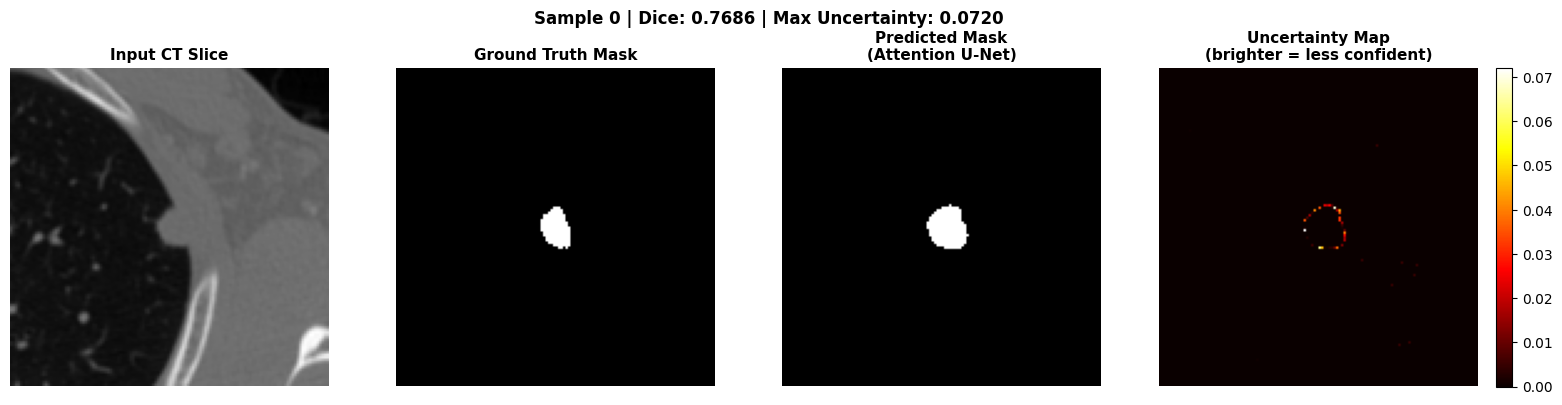

Saved: uncertainty_sample_0.png


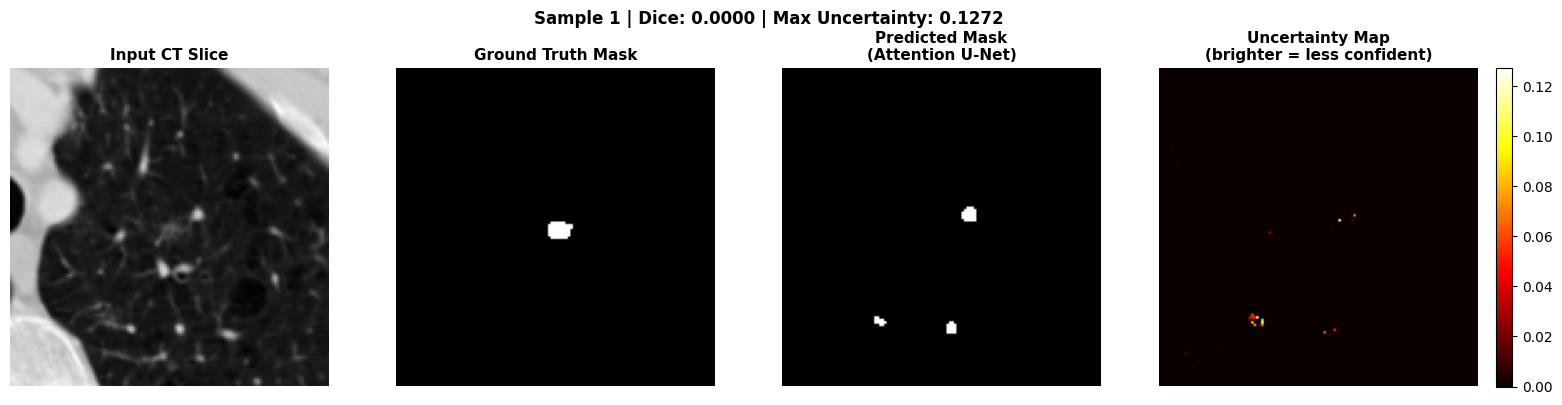

Saved: uncertainty_sample_1.png


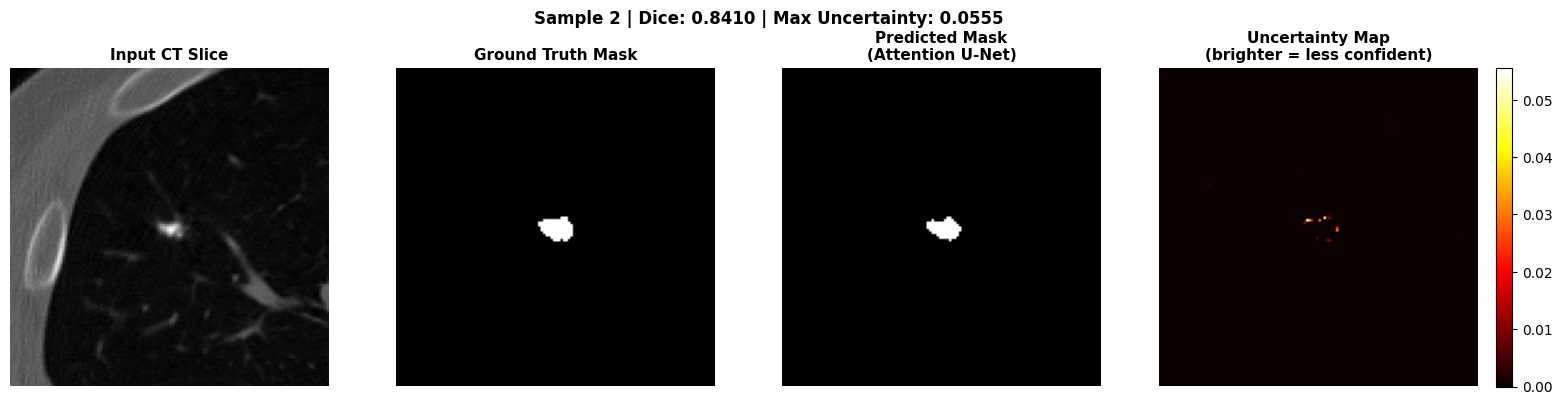

Saved: uncertainty_sample_2.png


In [ ]:
def visualize_uncertainty(model, X_val, Y_val, idx=0, n_passes=20):
    volume  = X_val[idx]
    gt_mask = Y_val[idx]

    mean_pred, uncertainty = mc_dropout_predict(model, volume, n_passes=n_passes)
    pred_binary = (mean_pred > 0.5).astype(np.float32)

    slice_idx = volume.shape[0] // 2  # middle slice

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(volume[slice_idx, :, :, 0], cmap='gray')
    axes[0].set_title('Input CT Slice', fontsize=11, weight='bold')
    axes[0].axis('off')

    axes[1].imshow(gt_mask[slice_idx, :, :, 0], cmap='gray')
    axes[1].set_title('Ground Truth Mask', fontsize=11, weight='bold')
    axes[1].axis('off')

    axes[2].imshow(pred_binary[slice_idx, :, :, 0], cmap='gray')
    axes[2].set_title('Predicted Mask\n(Attention U-Net)', fontsize=11, weight='bold')
    axes[2].axis('off')

    unc_map = uncertainty[slice_idx, :, :, 0]
    im = axes[3].imshow(unc_map, cmap='hot')
    axes[3].set_title('Uncertainty Map\n(brighter = less confident)', fontsize=11, weight='bold')
    axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    dice = compute_dice_np(gt_mask, mean_pred)
    plt.suptitle(
        f'Sample {idx} | Dice: {dice:.4f} | Max Uncertainty: {unc_map.max():.4f}',
        fontsize=12, weight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'uncertainty_sample_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: uncertainty_sample_{idx}.png")

# Visualize 3 samples
for i in [0, 1, 2]:
    visualize_uncertainty(model_attn, X_val, Y_val, idx=i, n_passes=20)

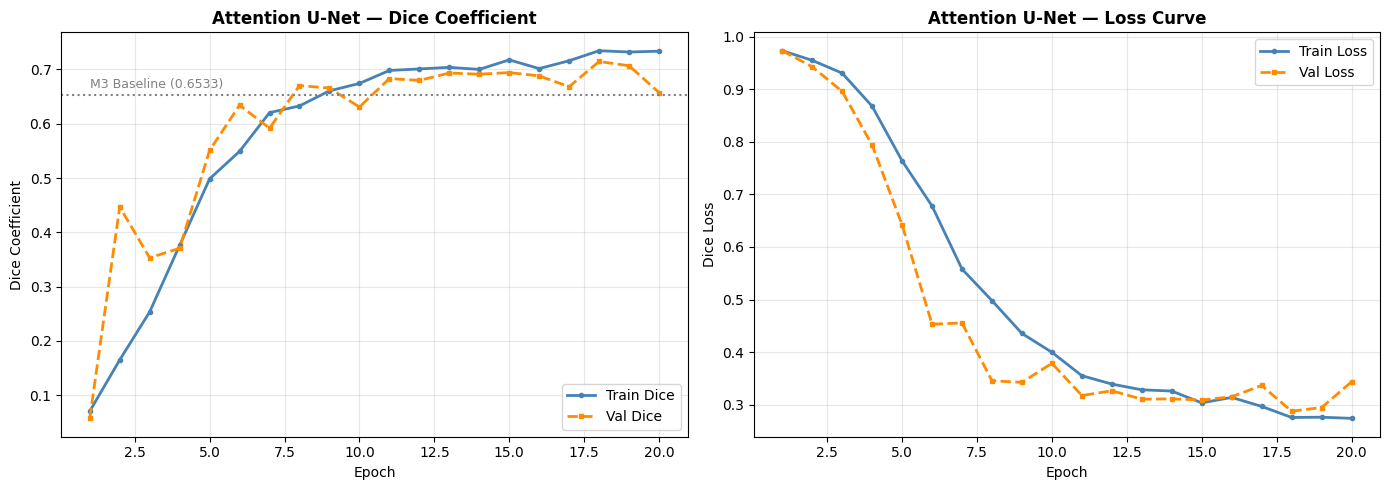

Saved: m4_training_curves.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['dice_coefficient']) + 1)

ax1.plot(epochs_range, history.history['dice_coefficient'],
         label='Train Dice', color='steelblue', lw=2, marker='o', ms=3)
ax1.plot(epochs_range, history.history['val_dice_coefficient'],
         label='Val Dice', color='darkorange', lw=2, marker='s', ms=3, linestyle='--')
ax1.axhline(y=0.6533, color='gray', linestyle=':', lw=1.5)
ax1.text(1, 0.665, 'M3 Baseline (0.6533)', fontsize=9, color='gray')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Dice Coefficient')
ax1.set_title('Attention U-Net — Dice Coefficient', weight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history.history['loss'],
         label='Train Loss', color='steelblue', lw=2, marker='o', ms=3)
ax2.plot(epochs_range, history.history['val_loss'],
         label='Val Loss', color='darkorange', lw=2, marker='s', ms=3, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Loss')
ax2.set_title('Attention U-Net — Loss Curve', weight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('m4_training_curves.png', dpi=150)
plt.show()
print("Saved: m4_training_curves.png")

In [ ]:
def predict_segmentation(image_slice):
    # Fix — handle grayscale conversion BEFORE resize
    if image_slice is None:
        return None

    # Convert RGB to grayscale if needed
    if len(image_slice.shape) == 3 and image_slice.shape[2] == 3:
        img = cv2.cvtColor(image_slice, cv2.COLOR_RGB2GRAY)
    elif len(image_slice.shape) == 3 and image_slice.shape[2] == 4:
        img = cv2.cvtColor(image_slice, cv2.COLOR_RGBA2GRAY)
    else:
        img = image_slice

    # Resize and normalize
    img = cv2.resize(img, (128, 128))
    if img.max() > 1.0:
        img = img.astype(np.float32) / 255.0
    else:
        img = img.astype(np.float32)

    # Stack into 8 slices to match model input
    volume = np.stack([img] * 8, axis=0)[..., np.newaxis]

    # MC Dropout prediction
    mean_pred, uncertainty = mc_dropout_predict(model_attn, volume, n_passes=20)

    pred_binary = (mean_pred[4, :, :, 0] > 0.5).astype(np.float32)
    unc_map     = uncertainty[4, :, :, 0]

    # Compute confidence score
    confidence = float(1.0 - unc_map.mean()) * 100

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Input CT Slice', weight='bold', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(pred_binary, cmap='gray')
    axes[1].set_title('Predicted Tumor Mask', weight='bold', fontsize=11)
    axes[1].axis('off')

    im = axes[2].imshow(unc_map, cmap='hot')
    axes[2].set_title('Uncertainty Map\n(bright = low confidence)', weight='bold', fontsize=11)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    plt.suptitle(
        f'Model Confidence: {confidence:.1f}%  |  '
        f'Tumor Pixels: {int(pred_binary.sum())}',
        fontsize=12, weight='bold'
    )
    plt.tight_layout()

    return fig

# Launch
interface = gr.Interface(
    fn=predict_segmentation,
    inputs=gr.Image(label="Upload CT Scan Slice (any format)"),
    outputs=gr.Plot(label="Segmentation + Uncertainty"),
    title="🫁 Lung Tumor AI Assistant",
    description=(
        "Upload a CT scan slice. "
        "The Attention U-Net predicts the tumor mask. "
        "The uncertainty map shows where the model is less confident — "
        "bright regions should be reviewed by a radiologist."
    ),
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3eb23eac90427bff08.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
